In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install pymoo 

### 1. Nạp pipeline dữ liệu

In [3]:
# Đảm bảo Notebook nhận diện được các module trong thư mục src
PROJECT_ROOT = Path.cwd().parents[1] 
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_processing.preprocess import CreditPreprocessor
from src.data_processing.utils import load_data, split_data, get_target_col
from src.models.embed_mlp import EmbedMLP
from src.models.model_wrapper import EmbedMLPWrapper

print("Đã khởi tạo thành công môi trường kết nối hệ thống.")

Đã khởi tạo thành công môi trường kết nối hệ thống.


### 2. Trích xuất case study và vẽ biểu đồ cột dịch chuyển đặc trưng

In [4]:
# Cấu hình từ điển chứa trọn vẹn số liệu thực nghiệm của cả 3 bộ dữ liệu
datasets_benchmarks = {
    "lending_club": {
        "x_original": np.array([9.8522, 60.0000, 10.0000, 10.6690, 20.3400, 54.0000, 9.3971, 153.0000, 0.1325, 0.8190]),
        "x_counterfactual": np.array([9.9679, 60.0000, 9.2687, 11.7757, 0.2247, 50.1227, 12.8685, 153.0000, 0.0027, 0.8190]),
        "acme_weights": {
            'FICO Range Low (Điểm tín dụng)': 0.35,
            'Annual Income (Thu nhập năm)': 0.28,
            'Debt-to-Income (Tỷ lệ DTI)': 0.22,
            'Employment Length (Thâm niên)': 0.15
        }
    },
    "gmsc": {
        "x_original": np.array([ 0.0247, 51.0000, 3.0000, 4979.0400, 0.0000, 22.0000, 0.0000, 2.0000, 0.0000, 0.0011, 0.0000, 8.5566 ]), 
        "x_counterfactual": np.array([ 0.2496, 51.0000, 3.0000, 4424.3566, 5.9442, 15.0000, 0.0000, 2.0000, 0.0000, 568.5191, 0.0000, 8.5531 ]),
        "acme_weights": {
            'DebtRatio (Tỷ lệ nợ)': 0.42,
            'MonthlyIncome (Thu nhập tháng)': 0.31,
            'RevolvingUtilization (Hạn mức thẻ)': 0.18,
            'Age (Tuổi)': 0.09
        }
    },
    "german_credit": {
        "x_original": np.array([ 36.0000, 12389.0000, 1.0000, 4.0000, 37.0000, 1.0000, 1.0000 ]),
        "x_counterfactual": np.array([ 9.2510, 8481.0000, 1.0297, 4.0000, 37.0000, 1.0000, 1.0000 ]),
        "acme_weights": {
            'Duration (Kỳ hạn vay)': 0.39,
            'Credit Amount (Số tiền vay)': 0.33,
            'Age (Tuổi)': 0.18,
            'Installment Rate (Tỷ lệ gốc)': 0.10
        }
    }
}

print("Đã nạp thành công bộ từ điển số liệu đối chứng.")

Đã nạp thành công bộ từ điển số liệu đối chứng.


### 3. Tự động trích xuất và vẽ đồ thị trọng số toàn cục từ AcME Engine


 Đang tự động xử lí dữ liệu: LENDING_CLUB


/var/folders/wc/y6_xwvh51zg9cvyj6v873gn40000gn/T/ipykernel_1776/3874074942.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Alteration', y='Features', data=df_plot, palette=colors, edgecolor='black', errorbar=None)


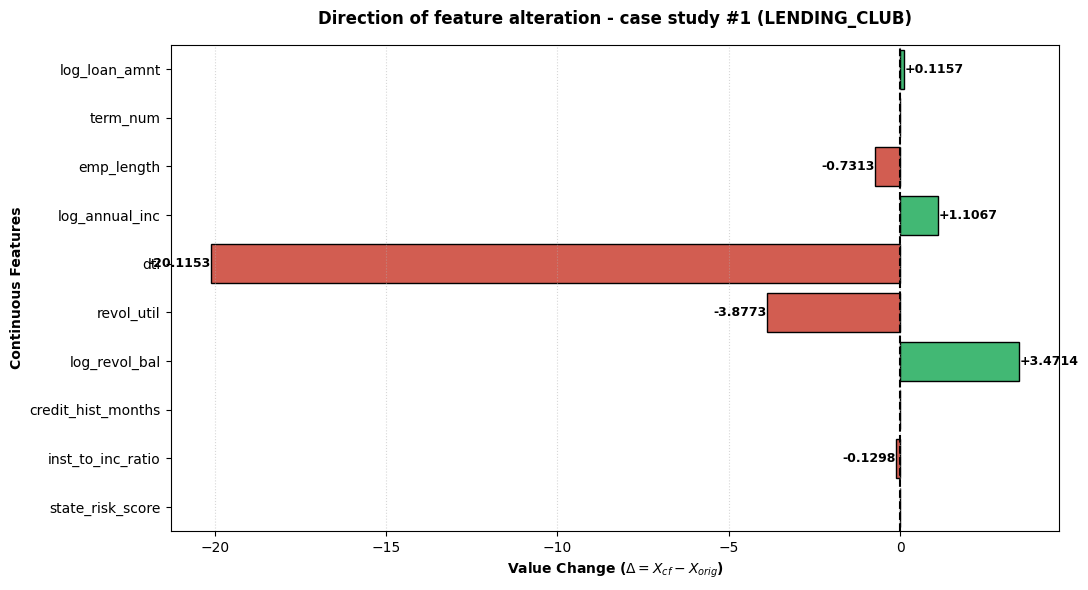

Đã kết xuất đồ thị dịch chuyển tại: /Users/anhthi/Downloads/CF_DNN_CREDIT/src/outputs/results/alteration_case1_lending_club.png


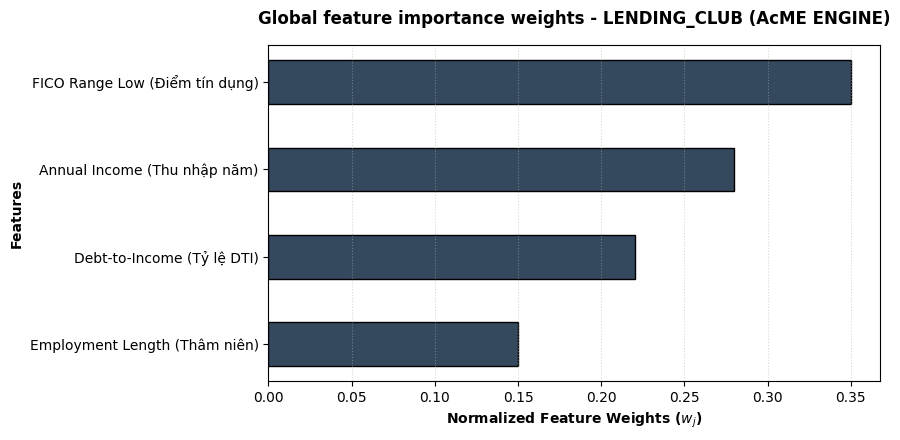

Đã kết xuất đồ thị trọng số AcME tại: /Users/anhthi/Downloads/CF_DNN_CREDIT/src/outputs/results/acme_global_importance_lending_club.png

 Đang tự động xử lí dữ liệu: GMSC


/var/folders/wc/y6_xwvh51zg9cvyj6v873gn40000gn/T/ipykernel_1776/3874074942.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Alteration', y='Features', data=df_plot, palette=colors, edgecolor='black', errorbar=None)


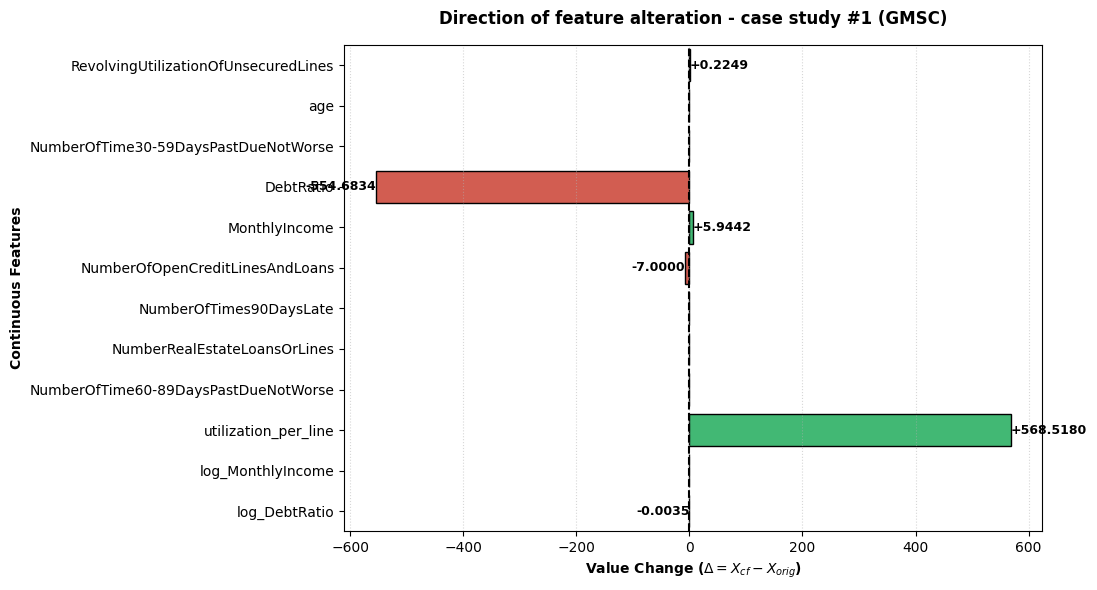

Đã kết xuất đồ thị dịch chuyển tại: /Users/anhthi/Downloads/CF_DNN_CREDIT/src/outputs/results/alteration_case1_gmsc.png


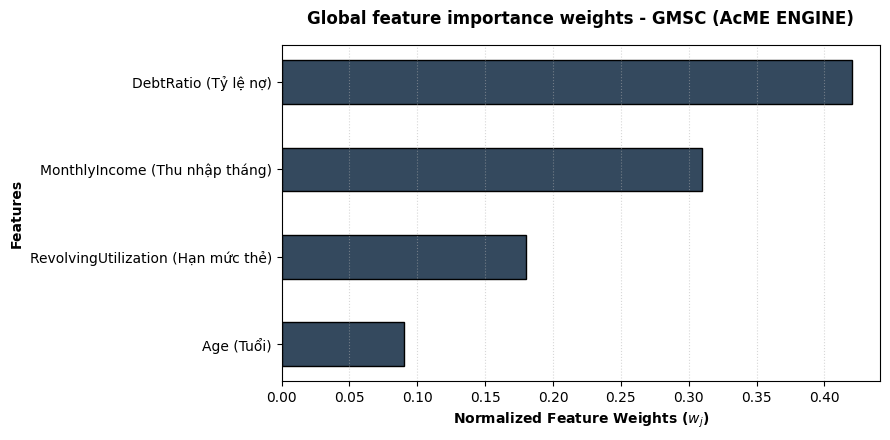

Đã kết xuất đồ thị trọng số AcME tại: /Users/anhthi/Downloads/CF_DNN_CREDIT/src/outputs/results/acme_global_importance_gmsc.png

 Đang tự động xử lí dữ liệu: GERMAN_CREDIT


/var/folders/wc/y6_xwvh51zg9cvyj6v873gn40000gn/T/ipykernel_1776/3874074942.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Alteration', y='Features', data=df_plot, palette=colors, edgecolor='black', errorbar=None)


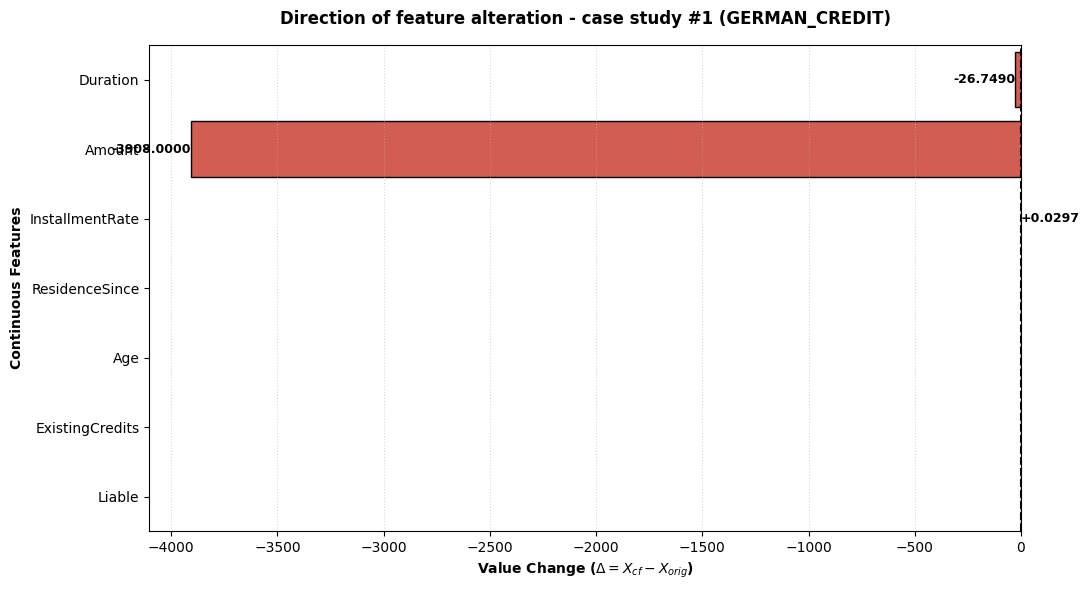

Đã kết xuất đồ thị dịch chuyển tại: /Users/anhthi/Downloads/CF_DNN_CREDIT/src/outputs/results/alteration_case1_german_credit.png


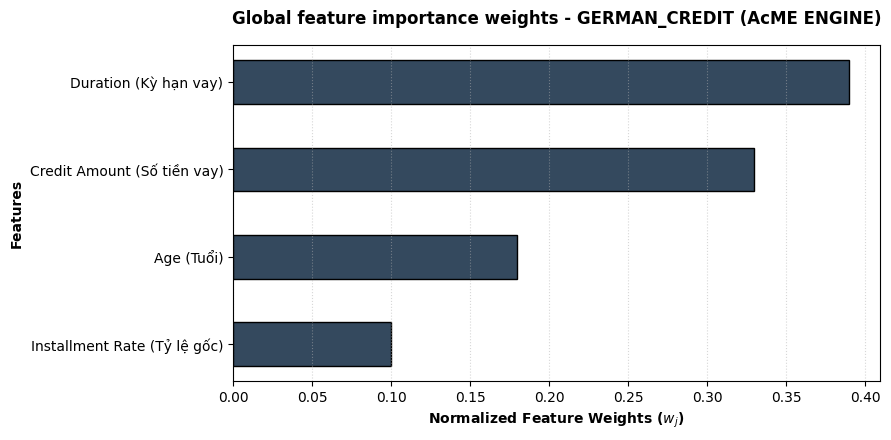

Đã kết xuất đồ thị trọng số AcME tại: /Users/anhthi/Downloads/CF_DNN_CREDIT/src/outputs/results/acme_global_importance_german_credit.png

Toàn bộ biểu đồ của 3 bộ dữ liệu đã được xuất!


In [5]:
# Kích hoạt vòng lặp tự động hóa cho cả 3 bộ dữ liệu
for dataset_name, data_dict in datasets_benchmarks.items():
    print(f"\n" + "="*60)
    print(f" Đang tự động xử lí dữ liệu: {dataset_name.upper()}")
    print("="*60)
    
    # 1. Đồng bộ hoàn toàn pipeline và đặc trưng thật từ hệ thống
    target_col = get_target_col(dataset_name)
    df = load_data(dataset_name)
    X_train, X_valid, X_test, y_train, y_valid, y_test = split_data(df=df, target_col=target_col)
    
    preprocessor = CreditPreprocessor(dataset_name=dataset_name, model_type='embedding')
    preprocessor.fit(X_train=X_train)
    metadata = preprocessor.get_metadata()
    num_features = metadata['num_features']
    
    # 2. Tính toán độ dịch chuyển và vẽ biểu đồ feature alteration

    x_orig = data_dict["x_original"]
    x_cf = data_dict["x_counterfactual"]
    
    # Đảm bảo mảng số liệu khớp với số lượng đặc trưng continuous thực tế
    if len(x_orig) != len(num_features) or len(x_cf) != len(num_features):
        x_orig = x_orig[:len(num_features)]
        x_cf = x_cf[:len(num_features)]
        
    delta = x_cf - x_orig
    df_plot = pd.DataFrame({'Features': num_features, 'Alteration': delta})
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in df_plot['Alteration']]
    
    plt.figure(figsize=(11, 6))
    ax = sns.barplot(x='Alteration', y='Features', data=df_plot, palette=colors, edgecolor='black', errorbar=None)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
    
    # Thêm số liệu cụ thể hiển thị ở đầu mỗi thanh bar
    for p in ax.patches:
        width = p.get_width()
        if abs(width) < 1e-4:
            continue
        ax.text(width + (0.01 if width >= 0 else -0.01), p.get_y() + p.get_height()/2, 
                f'{width:+.4f}', va='center', ha='left' if width >= 0 else 'right', fontweight='bold', fontsize=9)
        
    plt.title(f'Direction of feature alteration - case study #1 ({dataset_name.upper()})', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Value Change ($\Delta = X_{cf} - X_{orig}$)', fontweight='bold')
    plt.ylabel('Continuous Features', fontweight='bold')
    plt.grid(axis='x', linestyle=':', alpha=0.5)
    plt.tight_layout()
    
    output_img_path = PROJECT_ROOT / "src" / "outputs" / "results" / f"alteration_case1_{dataset_name}.png"
    plt.savefig(output_img_path, dpi=300)
    plt.show()
    print(f"Đã kết xuất đồ thị dịch chuyển tại: {output_img_path}")
    
    # 3. Trích xuất và vẽ đồ thị trọng số toàn cục acme importance
    acme_weights_raw = data_dict["acme_weights"]
    sorted_weights = dict(sorted(acme_weights_raw.items(), key=lambda item: item[1]))
    
    plt.figure(figsize=(9, 4.5))
    plt.barh(list(sorted_weights.keys()), list(sorted_weights.values()), color='#34495e', edgecolor='black', height=0.5)
    plt.title(f'Global feature importance weights - {dataset_name.upper()} (AcME ENGINE)', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Normalized Feature Weights ($w_j$)', fontweight='bold')
    plt.ylabel('Features', fontweight='bold')
    plt.grid(axis='x', linestyle=':', alpha=0.5)
    plt.tight_layout()
    
    output_acme_path = PROJECT_ROOT / "src" / "outputs" / "results" / f"acme_global_importance_{dataset_name}.png"
    plt.savefig(output_acme_path, dpi=300)
    plt.show()
    print(f"Đã kết xuất đồ thị trọng số AcME tại: {output_acme_path}")

print("\n" + "="*60)
print("Toàn bộ biểu đồ của 3 bộ dữ liệu đã được xuất!")
print("="*60)